# 一、词云图是什么？
- 一句话解释： <br>
  把出现次数越多的词放得越大、越醒目，次数少的词放得小一些，再随机排成一张图。
- 为什么叫“云”？ <br>
  因为这些词散落在画面里，像一团“云”，但这团云里藏着文本的核心内容。
- 适合用来： <br>
  快速看文章重点 <br>
  观察热点词  <br>
  做课堂展示（学生也喜欢这种直观结果 <br>

# 二、词云图的核心原理
- 其实它只有 3 个关键思想：<br>
① 先做词频统计：谁出现得多？<br>
你可以把文章想象成一个水果箱：<br>
• 苹果出现 25 次<br>
• 香蕉出现 10 次<br>
• 猕猴桃出现 3 次<br>
词语 = 水果 <br>
词频 = 水果数量 <br>
② 用词频来决定字体大小 <br>
出现越多 → 字越大 <br>
出现越少 → 字越小 <br>
比如：<br>
• “经济”这个词出现 500 次 → 字体很大 <br>
• “新能源”出现 210 次 → 字体中等 <br>
• “居民消费”出现 12 次 → 字体较小 <br>
③ 排布位置：像撒一把字到画布里 <br>
词云的底层算法会： <br>
• 给每个词计算一个合适的位置 <br>
• 避免它们重叠 <br>
• 可能根据掩膜图案（mask）生成特定形状（如心形、地图形状） <br>
可以理解为： <br>
把字一个个贴上去，但不能互相压住。

# 三、词云图的完整实现流程（中文文本）
用 jieba + wordcloud 的典型步骤如下：

1. 读文本
把文章从文件读进来：

In [1]:
text = open('datanew/news.txt', encoding='utf-8').read()

2. 清洗数据

In [2]:
import re
# 去除标点符号，只保留：中文、英文字母、数字、空格
text = re.sub(r"[^\w\s\u4e00-\u9fff]", " ", text)

3. 中文分词（必须） <br>
中文不像英文，有空格，因此先要断词：

In [3]:
import jieba
words = jieba.lcut(text)

C:\Users\Lenovo\miniconda3\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Lenovo\AppData\Local\Temp\jieba.cache
Loading model cost 0.298 seconds.
Prefix dict has been built successfully.


4. 去停用词（去掉无意义的词） <br>
比如 “的”，“了”，“和” 这种词对词云没意义。

In [4]:
stopwords = open('datanew/stopwords.txt', encoding='utf-8').read().split('\n')
words = [w for w in words if w not in stopwords and len(w) >= 2]

5. 统计词频
你可以用 Counter，也可以手动统计。

In [5]:
from collections import Counter
freqs = Counter(words)

关于 Counter(words) 做的事情：<br>
假设 words = ["中国","经济","中国","发展"] <br>
- 输入代码： <br>
- freqs = Counter(words) <br>
运行得到：<br>
- {'中国': 2, '经济': 1, '发展': 1}

6. 生成词云图
核心包：wordcloud
注意：中文必须提供 font_path 字体，否则会变成乱码方块。

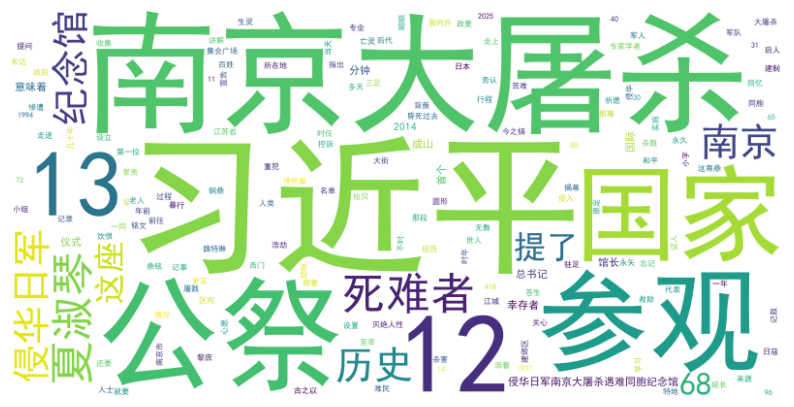

In [6]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",   # 使用windows自带中文字体
    width=800,
    height=400,
    background_color='white'
)

wc.generate_from_frequencies(freqs)

# 3. 在 Notebook 显示
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

#也可以保存到图片
wc.to_file("datanew/词云图.png")

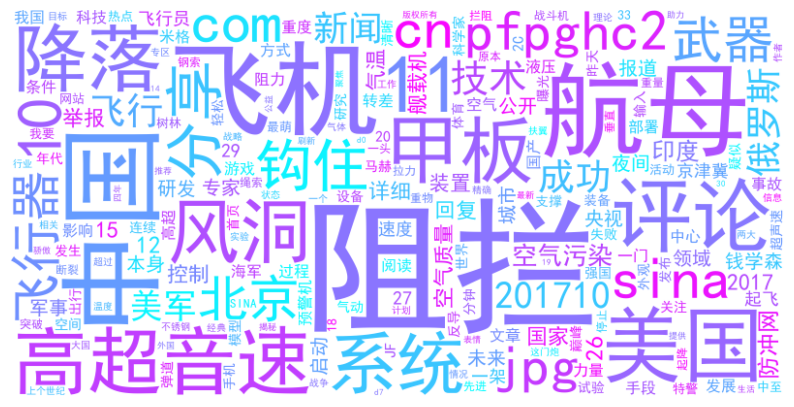

In [7]:
# 使用 colormap 实现渐变色词云
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# -------------------------------
# 1. 创建词云对象（加入 colormap）
# -------------------------------
wc = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",   # 中文字体
    width=800,
    height=400,
    background_color='white',
    colormap='cool'      # ★ 使用预置色盘，例如：pink, cool, plasma, viridis 等
)

# -------------------------------
# 2. 根据词频生成词云
# -------------------------------
wc.generate_from_frequencies(freqs)

# -------------------------------
# 3. 在 Notebook 中显示词云图
# -------------------------------
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# -------------------------------
# 4. 可选：保存成图片（PNG）
# -------------------------------
wc.to_file("datanew/colormap_词云图.png")

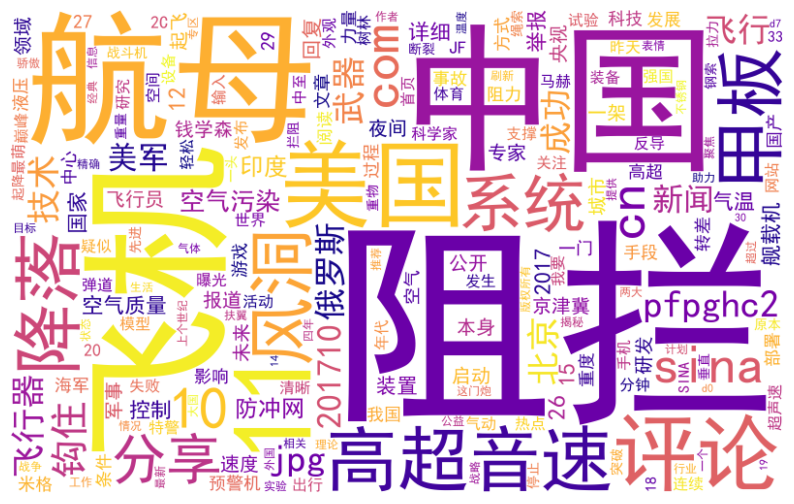

In [8]:
# 使用上下扩展布局 + 彩色渐变词云
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# -------------------------------
# 1. 创建词云对象（上下扩展 + 彩色渐变）
# -------------------------------
wc = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",   # 中文字体
    width=800,
    height=500,
    background_color='white',

    # ★ 控制词语方向（0.0~1.0）
    #   1.0 = 全水平
    #   0.0 = 全垂直
    #   0.5 = 水平和垂直各一半 → 形成“上下扩展”的视觉效果
    prefer_horizontal=0.5,

    # ★ 使用渐变 colormap 配色
    colormap='plasma',     # 推荐: plasma / cool / pink_r / viridis

    # ★ 可选：加入轮廓，让图像更立体
    contour_width=2,
    contour_color='black'
)

# -------------------------------
# 2. 根据词频生成词云
# -------------------------------
wc.generate_from_frequencies(freqs)

# -------------------------------
# 3. 显示词云
# -------------------------------
plt.figure(figsize=(10, 8))     # 高一些，让上下扩展效果更明显
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

# -------------------------------
# 4. 可保存为 PNG
# -------------------------------
wc.to_file("datanew/上下扩展彩色词云.png")

# 四、词云图背后的“算法小秘密”
- ① 按词频分配字体大小（最关键
- ② 从中心开始往外放置词语
### 词云的布局常用：
• 螺旋布局（spiral）
• 随机布局（random）
### 过程类似：
1. 先放最大词 → 居中
2. 再放第二大词 → 找个不重叠的位置
3. …
4. 找不到位置就往外“转圈圈”找
- ③ 可用“掩膜图（mask）”变出各种形状 <br>
如果给它一张猫咪轮廓图，它就会只在猫的形状里排布文字。<br>
mask = np.array(Image.open("cat.png")) <br>
wc = WordCloud(mask=mask, ...) <br>
排出来的词云就是猫形状，非常吸睛。

### 词云图和词频统计可以一次性读入多个文档，原理非常简单：
你把多个文档的内容拼成一个“大文本”，然后再一起分词、统计词频。<br>
一、通俗解释：多个文档一起分析是怎么做的？<br>
想象你有三份新闻稿：<br>
• 新闻1.txt <br>
• 新闻2.txt <br>
• 新闻3.txt <br>
做法非常简单：把它们的内容全部读出来，合并成一个长文本，然后像单文件一样处理。<br>
就像把三袋“文字水果”倒进一个大箱子里，一起数苹果、数橘子。<br>
| 步骤   | 单文件    | 多文件             |
| ---- | ------ | --------------- |
| 读数据  | 读一个文件  | `for文件 in文件夹`全读 |
| 分词   | 分一次    | 对合并文本分一次        |
| 统计词频 | 一份词频   | 多份合并后做词频        |
| 画词云  | 单个文本主题 | 多文档整体主题         |

In [9]:
# -------------------------------
# 1. 导入文件
# -------------------------------

import os  # 导入操作文件和文件夹的标准库 os

# 指定存放多个文本文件的文件夹路径
folder_path = "datanew/news"  # 你的文件夹，比如目录下有 news/新闻1.txt 等

texts = []  # 用一个空列表来存放每个文件读取到的文本内容

# 遍历这个文件夹中的所有文件名
for filename in os.listdir(folder_path):    
    # 只处理以 .txt 结尾的文件，防止里面有其他类型文件（比如 .DS_Store、图片等）
    if filename.endswith(".txt"):
        # 构造出这个文件的完整路径：文件夹路径 + 文件名
        file_path = os.path.join(folder_path, filename)
        
        # 以只读模式打开这个文本文件，指定 utf-8 编码，防止中文乱码
        with open(file_path, encoding="utf-8") as f:
            # 读取整个文件的内容（字符串），并追加到 texts 列表中
            texts.append(f.read())

# 把所有文件的文本用换行符 "\n" 拼接成一个“大文本字符串”
all_text = "\n".join(texts)

# 打印一下总字数，方便确认是否读取成功、内容大概有多少
print("总字数：", len(all_text))

总字数： 2947


In [10]:
# -------------------------------
# 2. 文本清洗（不写成函数）
# -------------------------------
import re

# 去除标点符号，只保留：中文、英文字母、数字、空格
cleaned_text = re.sub(r"[^\w\s\u4e00-\u9fff]", " ", all_text)

# 去除多余空白（例如多个空格合并为一个）
cleaned_text = re.sub(r"\s+", " ", cleaned_text)

# 去除两端空白
cleaned_text = cleaned_text.strip()

In [11]:
# -------------------------------
# 3. 中文分词（jieba）
# -------------------------------
import jieba

# 使用 jieba.lcut 对整个文本进行分词
# 输入：all_text（一个很长的字符串，包含多个 txt 文本的合并）
# 输出：words（一个词语列表，例如 ["中国", "经济", "发展", ...]）
words = jieba.lcut(all_text)

In [12]:
# -------------------------------
# 4. 去停用词
# -------------------------------

# 打开停用词表文件 stopwords.txt
# 读取时要指定 encoding="utf-8"，否则可能出现中文乱码
# read().split() 会将文件按换行符拆成一个列表，例如 ["的", "了", "和", ...]
stopwords = open("datanew/stopwords.txt", encoding="utf-8").read().split()

# 对分词后的结果进行过滤，保留“非停用词”+“长度大于 1 的词”
# 条件 1：w not in stopwords   → 过滤掉“的 / 了 / 和 / 我们 / 它”等无意义词
# 条件 2：len(w) > 1           → 去掉单字词（如 “啊”“呢”“国”“中”）
words = [w for w in words if w not in stopwords and len(w) > 1]

In [13]:
# -------------------------------
# 5. 统计词频
# -------------------------------
from collections import Counter  # Counter 用于快速统计列表中每个元素出现的次数

# 使用 Counter 对 words 列表做词频统计
# words 是你已经完成分词 + 去停用词的结果
# freqs 的类型是 Counter 对象，它本质上就是一个字典：{词: 频数}
freqs = Counter(words)

In [14]:
# -------------------------------
# 6. 转成 pyecharts 词云需要的格式
# -------------------------------
# pyecharts.WordCloud() 要求的数据格式是一个 list，如：
# [("中国", 120), ("经济", 85), ("发展", 66), ...]
# 因此需要将 Counter 里的 key-value（词 → 频数）转换成二元组列表

wordfreqs = [(w, int(f)) for w, f in freqs.items()]

In [17]:
# 导入所需要的模块
import pyecharts.options as opts
from pyecharts.charts import WordCloud

# -------------------------------
# 7. 创建词云图并配置参数
# -------------------------------
(
    WordCloud()                           # 创建一个 WordCloud 图表对象
    .add(
        series_name="",                   # 图例名称，可以留空，表示不显示图例文字
        data_pair=wordfreqs,              # 词频数据：形如 [("中国", 100), ("经济", 80), ...]
        word_size_range=[20, 100]         # 词语字体大小范围（最小字号 20，最大字号 100）
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="多文档词频分析",        # 图表标题，显示在网页上方
            title_textstyle_opts=opts.TextStyleOpts(
                font_size=23              # 标题字体大小
            )
        ),
        tooltip_opts=opts.TooltipOpts(
            is_show=True                  # 开启鼠标悬停提示：指到某个词时显示词频
        ),
    )
    .render("datanew/output/多文档词云图.html")   # 将图表渲染成交互式 HTML 文件，保存在指定路径
)

'E:\\课件\\非全金融数据分析\\05-初识文本分析\\datanew\\output\\多文档词云图.html'

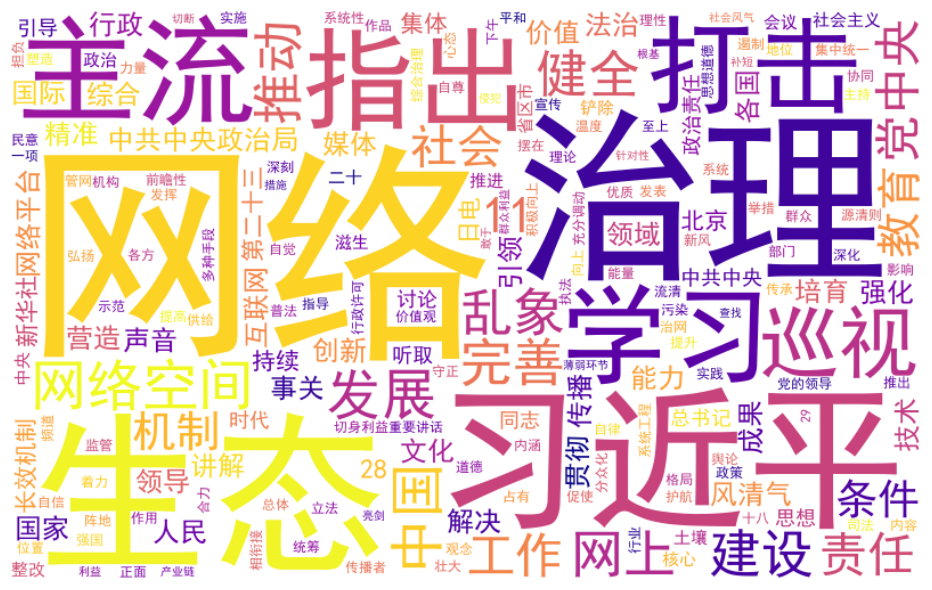

In [16]:
# matplotlib 版本词云
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(
    font_path="C:/Windows/Fonts/simhei.ttf",   # 必须提供中文字体
    width=800,
    height=500,
    background_color='white',                 # 背景色
    colormap='plasma',                        # 渐变色方案，可换（cool, pink_r, viridis 等）
    prefer_horizontal=0.9,                    # 绝大部分词横向排列，更美观
)

wc.generate_from_frequencies(freqs)           # freqs = Counter(words)

# 显示词云图（matplotlib）
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.tight_layout()
plt.show()


# 保存成 PNG 图片

wc.to_file("datanew/词云图_matplotlib版本.png")

# 练习-词频统计
使用jieba对新闻.txt 做词频统计，步骤：

1. 读取txt文件，得到中文数据
2. 清洗数据
3. 分词，得到词语列表和词语集合。
4. 去停用词
5. 记录词频
6. 转成 pyecharts 词云需要的格式
7. 存储

# ✅ **一、代码实现需要的提示词（Prompt 模板）**

这些提示词是为课堂 / 作业设计的，让学生可以用 ChatGPT 或其他大模型辅助写代码 ——
**但不直接给答案，而是让学生思考、理解流程。**
（符合教学场景，不会让学生直接复制最终代码）

---

## 🎯 **提示词模板：文本分析完整流程版**

### **提示词 1：读取并合并多个文本文件**

> **请帮我写一段 Python 代码：从一个指定文件夹中读取所有 `.txt` 文件，并将它们的内容合并成一个长文本字符串。代码必须包含逐行注释，并解释每一行的作用。**

---

### **提示词 2：对文本进行基础清洗**

> **请帮我写一段“文本清洗”代码，对输入文本进行如下处理：
> ① 去除标点符号
> ② 只保留中文、英文、数字
> ③ 合并多余空格
> 请给出逐行中文注释。**

---

### **提示词 3：使用 jieba 对清洗后的文本进行分词**

> **请帮我写一段使用 `jieba.lcut()` 进行中文分词的代码，并说明分词的结果是什么结构。请加入详细注释。**

---

### **提示词 4：导入停用词并进行过滤**

> **请帮我写一段 Python 代码：读取一个停用词文件 `stopwords.txt`，将停用词从分词列表中删除，并保留长度大于 1 的有效词。请逐行加注释并解释每一步。**

---

### **提示词 5：统计词频（Counter 实现）**

> **请帮我写一段使用 `collections.Counter` 统计词频的代码，并将结果转换为 `[("词语", 频数)]` 的列表格式，要求逐行注释。**

---

### **提示词 6：使用 pyecharts 绘制词云图**

> **请帮我写一段用 `pyecharts.WordCloud` 绘制词云图的代码，要求：
>
> * 能设置字体大小范围
> * 有标题
> * 可鼠标悬浮显示词频
> * 渲染成 HTML
>   并为每行代码添加中文注释。**

---

### **提示词 7：把整个流程串成一段完整代码（不写函数）**

> **请将“多文件读取 → 文本清洗 → 分词 → 去停用词 → 词频统计 → 词云图绘制”串成一个完整的 Notebook 代码单元，不使用函数，要求每个步骤标题+分隔线+中文解释。**

---

以上提示词可作为课堂“AI 助教提示”。

---

# ✅ **二、练习题设计（含难度梯度 + 不给答案）**

这些练习是为本章“词频统计 + 词云图”设计的，非常适合学生上机操作。

---

# 📘 **练习题（可写入 Notebook 最后一部分）**

---

## **练习题 1：读取多文档**

**题目：**
请从你自己的 `news/` 文件夹中读取至少 3 个 `.txt` 文档，将它们的内容合并成一个字符串，并打印总字数。

**要求：**

* 不能写函数
* 必须使用 `os.listdir`
* 打印每个文件的字数和总字数

---

## **练习题 2：完成文本清洗**

**题目：**
对合并后的文本进行清洗，去掉标点符号、特殊字符和多余空格。

**提示：**
使用 `re.sub()`
但你需要自己写出正则表达式。

---

## **练习题 3：分词 + 停用词过滤**

**题目：**
使用 `jieba` 分词并过滤停用词。

**要求：**

* 对比过滤前 vs 过滤后的词数
* 解释停用词为什么重要

---

## **练习题 4：统计 TOP20 高频词语**

**题目：**
使用 `Counter` 统计词频，并打印出现次数最高的 20 个词语。

**要求：**

* 输出格式：`词语 - 次数`
* 排序必须正确

---

## **练习题 5：绘制词云图（pyecharts）**

**题目：**
将你的词频结果绘制成词云图。

**要求：**

* 自定义词云标题
* 调整 `word_size_range`
* 将 HTML 文件保存到 `output/`

---

## **练习题 6：自定义分析（开放题）**

**题目：**
任选一个你关心的话题或新闻来源，收集至少 5 篇文本，自行完成“清洗 → 分词 → 词频 → 词云”全流程，并总结你的观察。

**要求：**

* 上传最终的词云图
* 写一段 100 字以上的分析报告

---

# 练习 1 参考答案：读取并合并多个 txt 文件
``` python
import os

folder_path = "news"   # 存放新闻文本的文件夹
texts = []              # 用来存放每个文件的内容
total_chars = 0         # 统计总字数

for filename in os.listdir(folder_path):
    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path, filename)
        with open(file_path, encoding="utf-8") as f:
            content = f.read()
            texts.append(content)
            print(f"{filename} 字数：", len(content))
            total_chars += len(content)

# 合并所有文本为一个大字符串
all_text = "\n".join(texts)

print("合并后的总字数：", len(all_text))
print("累计统计的总字数：", total_chars)
```

# 练习 2 参考答案：文本清洗
``` python
import re

# all_text 来自练习 1
# 1. 去掉标点符号和特殊字符，只保留：中文、字母、数字、空格
cleaned_text = re.sub(r"[^\w\s\u4e00-\u9fff]", " ", all_text)

# 2. 合并多余空白（多个空格、换行、制表符等 → 1 个空格）
cleaned_text = re.sub(r"\s+", " ", cleaned_text)

# 3. 去掉首尾空格
cleaned_text = cleaned_text.strip()

print("清洗前字数：", len(all_text))
print("清洗后字数：", len(cleaned_text))
print("清洗后前 200 个字符预览：")
print(cleaned_text[:200])
```

# 练习 3 参考答案：分词 + 去停用词
``` python
import jieba

# 1. 分词（对 cleaned_text 而不是 all_text 分词）
words_raw = jieba.lcut(cleaned_text)
print("分词后总词数（未去停用词）：", len(words_raw))

# 2. 读取停用词表
with open("stopwords.txt", encoding="utf-8") as f:
    stopwords = f.read().split()

# 3. 过滤停用词 + 去掉长度为 1 的词
words = [w for w in words_raw if w not in stopwords and len(w) > 1]
print("去停用词后总词数：", len(words))

# 简单看一下前 30 个词
print("过滤后前 30 个词：")
print(words[:30])
```

# 练习 4 参考答案：统计高频词
``` python
from collections import Counter

# words 来自练习 3（分词 + 去停用词后的结果）
freqs = Counter(words)

# most_common(20) 返回出现频率最高的 20 个 (词, 次数)
top20 = freqs.most_common(20)

print("出现次数最高的 20 个词：")
for word, freq in top20:
    print(f"{word} - {freq}")
```

# 练习 5 参考答案：pyecharts 词云图
``` python
import pyecharts.options as opts
from pyecharts.charts import WordCloud

# 将 Counter 的结果转成 pyecharts 需要的 [(词, 频数)] 格式
wordfreqs = [(w, int(f)) for w, f in freqs.items()]

# 创建词云并设置参数
(
    WordCloud()
    .add(
        series_name="",
        data_pair=wordfreqs,
        word_size_range=[20, 100]  # 词语字号范围
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(
            title="多文档词频分析词云图",
            title_textstyle_opts=opts.TextStyleOpts(font_size=24)
        ),
        tooltip_opts=opts.TooltipOpts(is_show=True),
    )
    .render("output/多文档词云图.html")
)

print("词云图已生成为：output/多文档词云图.html")
'''

#### 练习6 是开放题
##### 1. 学生将 5 篇文档放入 my_corpus/ 文件夹。
##### 2. 代码整体与前面的 练习 1～5 完全相同，只是把 folder_path 改成 "my_corpus"。
##### 3. 可以增加一个小步骤：只保留前 200 个高频词来画词云，避免噪音太多。
folder_path = "my_corpus"   # 自己收集的语料文件夹
##### 后续读取 / 清洗 / 分词 / 去停用词 / 词频统计等步骤同前
``` python
# 只用 top 200 高频词来画词云
top200 = freqs.most_common(200)
wordfreqs_top200 = [(w, int(f)) for w, f in top200]

(
    WordCloud()
    .add("", wordfreqs_top200, word_size_range=[20, 100])
    .set_global_opts(
        title_opts=opts.TitleOpts(title="自定义语料词云分析"),
        tooltip_opts=opts.TooltipOpts(is_show=True),
    )
    .render("output/自定义语料词云图.html")
)
···